In [1]:
pwd

'/home/bhumikas/DronesRF/DroneRFb_Spectra'

In [4]:
pip install tensorflow

  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached ml_dtypes-0.5.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
  Using cached tensorflow_io_gcs_filesystem-0.37.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using 

In [5]:
import tensorflow as tf

2025-06-14 10:58:22.310575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-14 10:58:22.322638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749898702.334879    6551 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749898702.338421    6551 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749898702.348456    6551 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import BatchNormalization
from sklearn import metrics
from sklearn.metrics import classification_report
import time
from tqdm import tqdm

In [7]:
from tensorflow.python.client import  device_lib
device_lib.list_local_devices()

W0000 00:00:1749898704.586172    6551 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 8797833046956764517
 xla_global_id: -1]

In [8]:
# Set random seed for Python's built-in random number generator
import random
random_seed = 42
random.seed(random_seed)

# Set random seed for NumPy
np.random.seed(random_seed)

# Set random seed for TensorFlow
tf.random.set_seed(random_seed)

In [9]:
DATADIR = "/home/bhumikas/DronesRF/DroneRFb_Spectra/Condata/"
CATEGORIES = ["0", "1", "2", "3", "4", "5","6", "7", "8", "9","10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]
dataset = []
img_size = (64, 64)
max_images_per_class = 200  # Total required images (5000 for train, 1000 for test, 1000 for validation)

# Step 1: Load images
for category in tqdm(CATEGORIES):  
    path = os.path.join(DATADIR, category)  
    class_num = CATEGORIES.index(category)
    image_count = 0
    for img in os.listdir(path):
        if image_count >= max_images_per_class:
            break
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
            image_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
            new_array = cv2.resize(image_rgb, img_size)
            dataset.append([new_array, class_num])
            image_count += 1
        except Exception as e:
            pass

# Step 2: Separate features (X) and labels (Y)
X = [] # features
Y = [] # labels

for features, label in dataset:
    X.append(features)
    Y.append(label)


100%|██████████| 24/24 [00:24<00:00,  1.04s/it]


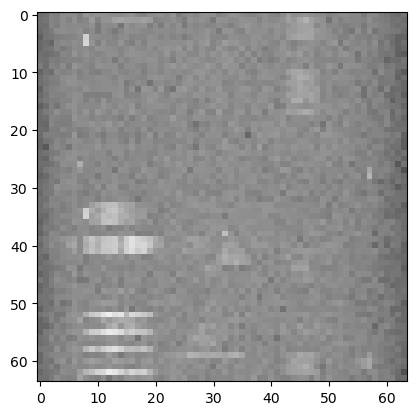

In [10]:
import matplotlib.pyplot as plt
 
plt.imshow(X[1])

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

X_train = np.array(X_train).reshape(-1, img_size[0], img_size[1], 3)
Y_train = np.array(Y_train).reshape(-1,)
#X_train = ( X_train)/255

X_test = np.array(X_test).reshape(-1,  img_size[0], img_size[1], 3)
Y_test = np.array(Y_test).reshape(-1,)
#X_test = (X_test)/255

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Custom Lightweight DenseNet-inspired Model
def create_custom_densenet(input_shape, num_classes, growth_rate=8, compression=0.5):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.BatchNormalization()(inputs)
    x = layers.Conv2D(growth_rate * 2, kernel_size=(3, 3), padding='same', activation='relu')(x)
    
    # Lightweight Dense Block
    def dense_block(x, num_layers, growth_rate):
        for _ in range(num_layers):
            out = layers.BatchNormalization()(x)
            out = layers.Conv2D(growth_rate, kernel_size=(3, 3), padding='same', activation='relu')(out)
            x = layers.Concatenate()([x, out])  # Concatenate input and output
        return x
    
    # Lightweight Transition Block
    def transition_block(x, compression):
        reduced_filters = int(x.shape[-1] * compression)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(reduced_filters, kernel_size=(1, 1), padding='same', activation='relu')(x)
        x = layers.AveragePooling2D(pool_size=(2, 2))(x)
        return x
    
    # Adding Dense Blocks and Transition Layers
    num_dense_layers = [3, 3, 3]  # Number of layers in each dense block
    for num_layers in num_dense_layers:
        x = dense_block(x, num_layers, growth_rate)
        x = transition_block(x, compression)
    
    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

# Create Model
model = create_custom_densenet(input_shape=(64, 64, 3), num_classes=24)

# Compile Model with Gradient Clipping
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0)  # Prevent gradient explosion
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


W0000 00:00:1749898729.744163    6551 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:


# Learning Rate Scheduler
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Train Model with Batch Size = 1 (SGD)
history = model.fit(X_train, Y_train, 
                    batch_size=5,  # Train with one sample at a time
                    epochs=30, 
                    validation_data=(X_test, Y_test), 
                    callbacks=[lr_scheduler])

Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 118s 148ms/step - accuracy: 0.1275 - loss: 2.8821 - val_accuracy: 0.2094 - val_loss: 2.2832 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 112s 145ms/step - accuracy: 0.3723 - loss: 2.0003 - val_accuracy: 0.5229 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 111s 145ms/step - accuracy: 0.5457 - loss: 1.3750 - val_accuracy: 0.6240 - val_loss: 0.9246 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 112s 145ms/step - accuracy: 0.6582 - loss: 0.9841 - val_accuracy: 0.7365 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 112s 145ms/step - accuracy: 0.7468 - loss: 0.7353 - val_accuracy: 0.8073 - val_loss: 0.5347 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 112s 146ms/step - accuracy: 0.8065 - loss: 0.5752 - val_accuracy: 0.8333 - val_loss: 0.4445 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 110s 144ms/step - accura

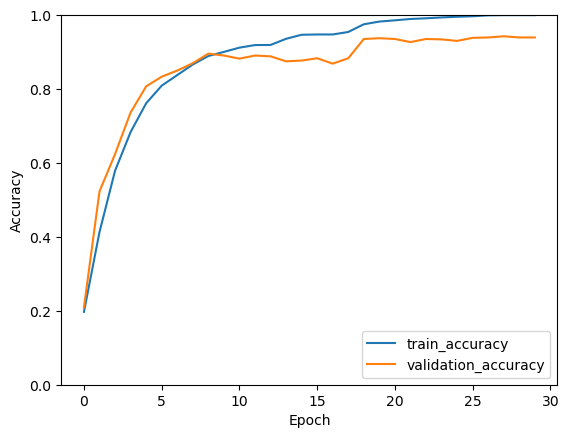

In [14]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
#plt.savefig('/home/ramck/Vidya/ResNet101V2.png')
plt.show()

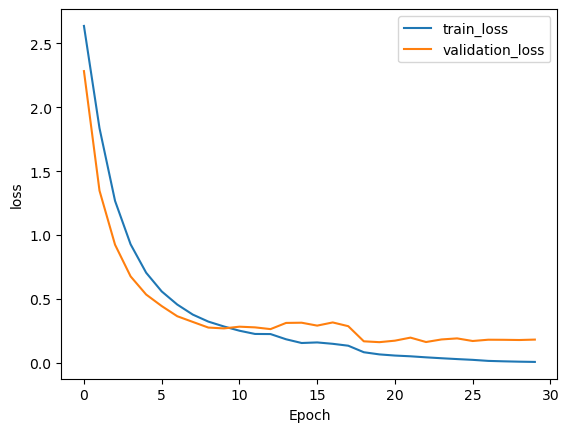

In [15]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label = 'validation_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
#plt.ylim([0, 1])
plt.legend(loc='upper right')
#plt.savefig('/home/ramck/Vidya/ResNet101V2_loss.png')
plt.show()

In [16]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64, 3) │         12 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        448 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64, 8) │      1,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 24)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64, 8) │      1,736 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64, 8) │      2,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ concatenate_1[0]… │
│ (Concatenate)       │ 40)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        160 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │        820 │ batch_normalizat… │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (AveragePooling2D)  │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         80 │ average_pooling2… │
│ (BatchNormalizatio… │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32, 8) │      1,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ average_pooling2… │
│ (Concatenate)       │ 28)               │            │ conv2d_5[0][0]  

 Total params: 68,131 (266.14 KB)

 Trainable params: 22,457 (87.72 KB)

 Non-trainable params: 758 (2.96 KB)

 Optimizer params: 44,916 (175.46 KB)

None


In [17]:
plot.model(model, show_shapes=True, to_file='/home/bhumikas/DronesRF/DroneRFb_Spectra/DenseNet_RF_CNN_Model_Architecture.png')

NameError: name 'plot' is not defined

30/30 - 3s - 93ms/step - accuracy: 0.9396 - loss: 0.1819
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
test accuracy = 93.95833333333333 %

              precision    recall  f1-score   support

           0       0.90      0.83      0.86        53
           1       1.00      1.00      1.00        42
           2       0.83      0.90      0.87        50
           3       0.74      0.92      0.82        37
           4       0.85      0.78      0.82        37
           5       1.00      0.98      0.99        51
           6       0.97      1.00      0.98        32
           7       0.85      0.66      0.74        44
           8       0.92      1.00      0.96        35
           9       0.97      0.97      0.97        35
          10       1.00      1.00      1.00        30
          11       1.00      0.95      0.98        42
          12       1.00      0.96      0.98        56
          13       1.00      1.00      1.00        30
          14       0.78      1.00      0.88        32
 

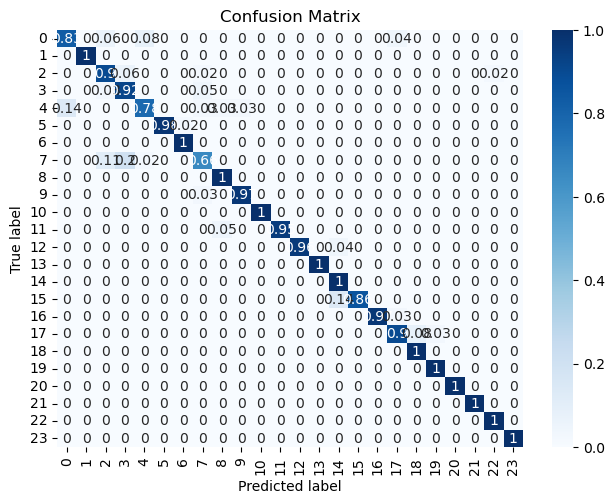

In [18]:
test_loss, test_acc = model.evaluate(X_test,  Y_test, verbose=2)
Y_te = np.array(tf.math.argmax(model.predict(X_test), 1))
cm = tf.math.confusion_matrix(Y_test, Y_te)


acc = metrics.accuracy_score(Y_test, Y_te)
print("test accuracy =", acc*100,"%\n")

print(classification_report(Y_test, Y_te))

con_mat = tf.math.confusion_matrix(labels=Y_test, predictions=Y_te).numpy()

con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)
classes = ["0", "1", "2", "3", "4", "5","6", "7", "8", "9","10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]

con_mat_df = pd.DataFrame(con_mat_norm,
                     index = classes,
                     columns = classes)
figure = plt.figure()
sns.heatmap(con_mat_df, annot=True, cmap="Blues")
plt.tight_layout()
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
# Set the figure size (in inches)
 # Width, Height
#plt.savefig('/home/nandams/machine_fault_classification/figures/0db/confusion_matrix.jpg', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [19]:
model.save('home/bhumikas/DronesRF/DroneRFb_Spectra/att_backbone.h5')

In [20]:
pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [21]:
from tensorflow.keras.utils import plot_model

In [22]:
plot_model(model, show_shapes=True, to_file='/home/bhumikas/DronesRF/DroneRFb_Spectra/DenseNet_RF_CNN_Model_Architecture.png')

You must install pydot (`pip install pydot`) for `plot_model` to work.
